In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('./47._Indicadores_de_Salud_municipio_de_Bucaramanga_20260407.csv')
df

FileNotFoundError: [Errno 2] No such file or directory: './47._Indicadores_de_Salud_municipio_de_Bucaramanga_20260407.csv'

In [ ]:
df[['Año', 'Tasa Natalidad', 'Tasa fecundidad gral']].head()

,Año,Tasa Natalidad,Tasa fecundidad gral
0,2008,18.14,63.14
1,2009,16.85,59.00
2,2010,16.03,56.55
3,2011,16.88,60.02
4,2012,17.38,62.31


In [ ]:
print(df['Año'].value_counts())
df = df.drop_duplicates(subset=['Año'], keep='first')

Año
2008    2
2009    2
2010    2
2011    2
2012    2
2013    2
2014    2
2015    2
2016    2
2017    2
2018    2
2019    2
2020    2
2021    2
Name: count, dtype: int64


In [ ]:
df

,COD,Deptos,cod_mun,Municipio,Año,Tasa Natalidad,# nacimientos,Tasa fecundidad gral,Mujer 15 a 49 años,Mujer 10 a 49 años,...,Tasa Incidencia Violencia de genero,Casos Violencia >60 años,Tasa Incidencia Violencia >60 años,Casos Violencia < 5 años,Tasa Incidencia Violencia < 5 años,Tasa de mortalidad en < 5 años por EDA,% Nacidos con bajo peso > o = 37 sem,Tasa mortalida perinatal,Tasa fecund. 10-14 años,Tasa fecund. 15-19 años
0,68.001,SANTANDER,68.001,Bucaramanga,2008,18.14,9.457,63.14,149.769,172.174,...,0.00,0,0.00,0,0,0.00,NaN,NaN,NaN,NaN
1,68.001,SANTANDER,68.001,Bucaramanga,2009,16.85,8.807,59.00,149.264,171.436,...,263.72,99,167.46,5,10.89,2.63,NaN,NaN,NaN,NaN
2,68.001,SANTANDER,68.001,Bucaramanga,2010,16.03,8.402,56.55,148.569,170.459,...,297.37,121,199.27,8,17.65,2.66,NaN,NaN,NaN,NaN
3,68.001,SANTANDER,68.001,Bucaramanga,2011,16.88,8.866,60.02,147.724,169.288,...,469.13,342,548.94,34,76.05,0.00,NaN,NaN,NaN,NaN
4,68.001,SANTANDER,68.001,Bucaramanga,2012,17.38,9.142,62.31,146.727,167.894,...,389.89,271,423.62,256,580.58,2.73,NaN,NaN,NaN,NaN
5,68.001,SANTANDER,68.001,Bucaramanga,2013,17.65,9.299,63.86,145.626,166.345,...,288.61,317,482.49,317,729.32,0.00,NaN,NaN,NaN,NaN
6,68.001,SANTANDER,68.001,Bucaramanga,2014,17.87,9.423,65.22,144.476,164.723,...,253.51,323,478.20,398,929.28,0.00,NaN,NaN,NaN,NaN
7,68.001,SANTANDER,68.001,Bucaramanga,2015,18.36,9.693,67.65,143.287,163.085,...,0.00,0,0.00,522,"1,237.32",2.86,NaN,NaN,NaN,NaN
8,68.001,SANTANDER,68.001,Bucaramanga,2016,13.51,7.139,44.20,161.533,321.707,...,0.00,0,0.00,0,0,2.91,NaN,NaN,NaN,NaN
9,68.001,SANTANDER,68.001,Bucaramanga,2017,14.60,7.739,54.90,140.877,160.034,...,266.79,37,5.02,478,116.88,0.00,NaN,NaN,NaN,NaN


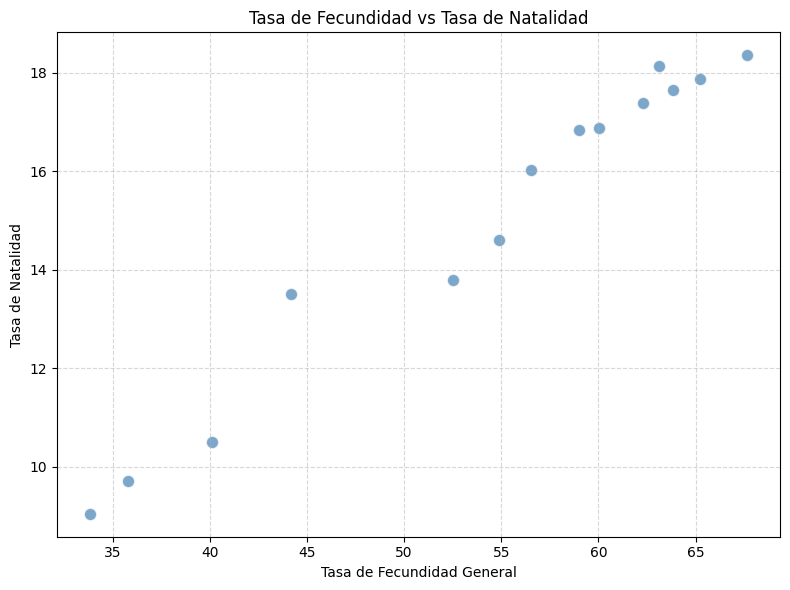

In [ ]:
import matplotlib.pyplot as plt

df_clean = df.dropna(subset=['Tasa fecundidad gral', 'Tasa Natalidad'])
plt.figure(figsize=(8, 6))
plt.scatter(df_clean['Tasa fecundidad gral'], df_clean['Tasa Natalidad'],
            color='steelblue', alpha=0.7, edgecolors='white', s=80)
plt.xlabel('Tasa de Fecundidad General')
plt.ylabel('Tasa de Natalidad')
plt.title('Tasa de Fecundidad vs Tasa de Natalidad')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
def calculate_regression_params(df, var1, var2):
    """
    Calcula todos los parámetros de regresión de una vez
    """
    n = np.size(df[var1])
    x_barra = np.mean(df[var1])
    y_barra = np.mean(df[var2])
    
    numerator = np.sum(df[var1] * df[var2]) - n * (x_barra * y_barra)
    denominator = np.sum(df[var1]**2) - n * (x_barra**2)
    Br = numerator / denominator
    
    Bo = y_barra - (Br * x_barra)
    
    return Br, Bo, x_barra, y_barra

In [ ]:
Br_calculado, Bo_calculado, x_barra, y_barra = calculate_regression_params(
    df, 'Tasa fecundidad gral', 'Tasa Natalidad'
)

print(f"Br: {Br_calculado:.4f}")
print(f"Bo: {Bo_calculado:.4f}")
print(f"x_barra: {x_barra:.4f}")
print(f"y_barra: {y_barra:.4f}")

Br: 0.2838
Bo: -0.3633
x_barra: 54.2179
y_barra: 15.0221


/tmp/ipykernel_228533/1945242228.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


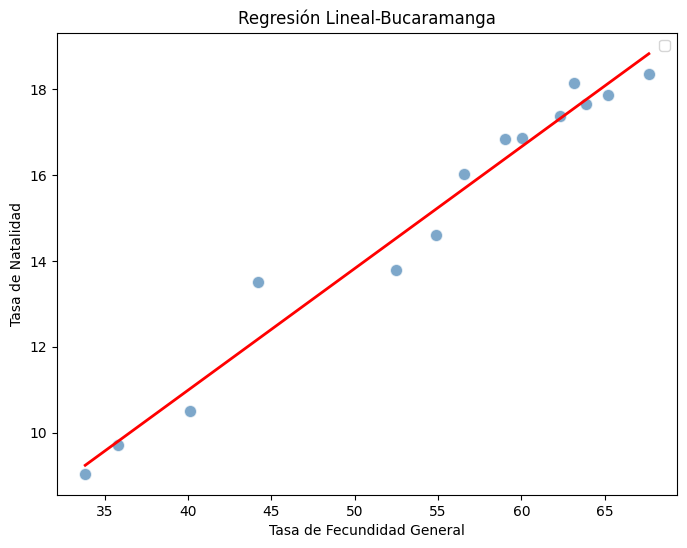

In [ ]:

x = df['Tasa fecundidad gral']
y = df['Tasa Natalidad']
x_line = np.linspace(x.min(), x.max(), 100)
y_line = Bo_calculado + Br_calculado * x_line
plt.figure(figsize=(8, 6))
plt.scatter(x, y, color='steelblue', alpha=0.7, edgecolors='white', s=80)
plt.plot(x_line, y_line, color='red', linewidth=2)
plt.xlabel('Tasa de Fecundidad General')
plt.ylabel('Tasa de Natalidad')
plt.title('Regresión Lineal-Bucaramanga')
plt.legend()
plt.show()

In [ ]:
x_nuevo = 45
y_predicho = Bo_calculado + Br_calculado * x_nuevo
print("la tasa de natalidad sera="+str(y_predicho))

la tasa de natalidad sera=12.406387155293384


In [ ]:
def calculate_ynuevo(df, x_nuevo, Bo_calculado, Br_calculado):
 y_predicho = Bo_calculado + Br_calculado * x_nuevo
 return y_predicho


In [ ]:
x_nuevo= 45
y_nuevo = calculate_ynuevo(df, x_nuevo, Bo_calculado, Br_calculado)
print("la tasa de natalidad sera="+str(y_nuevo))

la tasa de natalidad sera=12.406387155293384


In [ ]:
def calculate_sigma(df, fecundidad, natalidad, Br, Bo):
    n = np.size(df[fecundidad])
    y_predicho = Bo + Br * df[fecundidad]
    residuos = (df[natalidad] - y_predicho)**2
    sigma2 = np.sum(residuos) / (n - 2)
    sigma = np.sqrt(sigma2)
    print(np.sum(residuos))
    return sigma2, sigma


In [ ]:
sigma2, sigma = calculate_sigma(df, 'Tasa fecundidad gral', 'Tasa Natalidad', Br_calculado, Bo_calculado)
print(f"Sigma cuadrado {sigma2:.4f}")
print(f"Sigma {sigma:.4f}")

4.046584717099594
Sigma cuadrado 0.3372
Sigma 0.5807


In [ ]:
Br_calculado, Bo_calculado, x_barra, y_barra = calculate_regression_params(
    df, 'Tasa fecundidad gral', 'Tasa de Mortalidad Infantil (<1años)'
)

print(f"Br: {Br_calculado:.4f}")
print(f"Bo: {Bo_calculado:.4f}")
print(f"x_barra: {x_barra:.4f}")
print(f"y_barra: {y_barra:.4f}")

Br: 0.0990
Bo: 2.7077
x_barra: 54.2179
y_barra: 8.0771


/tmp/ipykernel_228533/1003549812.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


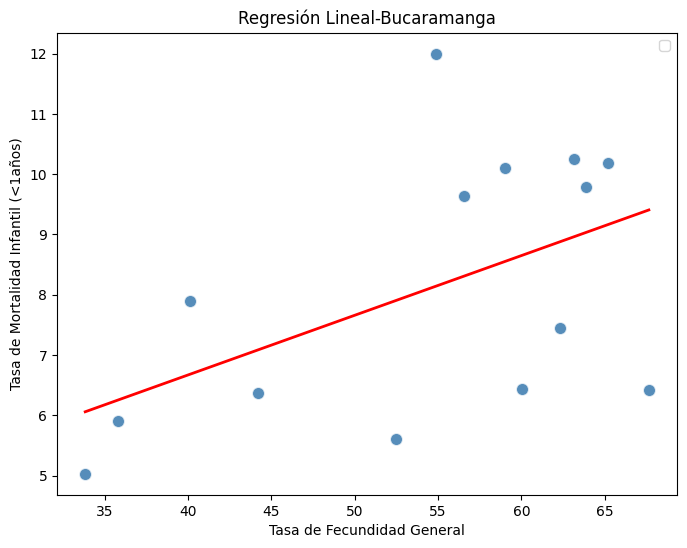

In [ ]:
x = df['Tasa fecundidad gral']
y = df['Tasa de Mortalidad Infantil (<1años)']
x_line = np.linspace(x.min(), x.max(), 100)
y_line = Bo_calculado + Br_calculado * x_line
plt.figure(figsize=(8, 6))
plt.scatter(x, y, color='steelblue', alpha=0.7, edgecolors='white', s=80)
plt.plot(x_line, y_line, color='red', linewidth=2)
plt.xlabel('Tasa de Fecundidad General')
plt.ylabel('Tasa de Mortalidad Infantil (<1años)')
plt.title('Regresión Lineal-Bucaramanga')
plt.legend()
plt.show()

In [ ]:
sigma2, sigma = calculate_sigma(df, 'Tasa fecundidad gral', 'Tasa de Mortalidad Infantil (<1años)', Br_calculado, Bo_calculado)
print(f"Sigma cuadrado {sigma2:.4f}")
print(f"Sigma {sigma:.4f}")     

93.62451793097101
Sigma cuadrado 3.6009
Sigma 1.8976


## Clase 14 abril


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- Parámetros de tu notebook ---
beta0_true = Bo_calculado   # -0.3633
beta1_true = Br_calculado   # 0.2838
# sigma ya está definido desde calculate_sigma()
np.random.seed(42)

# --- X reales de tu DataFrame ---
x = df['Tasa fecundidad gral'].values  # ✅ datos reales

# --- Recta verdadera ---
y_true = beta0_true + beta1_true * x

# --- Simular 3 muestras ---
simuladas = []
for i in range(3):
    ruido = np.random.normal(0, sigma, size=len(x))
    simuladas.append(y_true + ruido)

# --- Estimar betas OLS ---
def estimar_betas(x, y):
    x_mean, y_mean = np.mean(x), np.mean(y)
    b1 = np.sum((x - x_mean)*(y - y_mean)) / np.sum((x - x_mean)**2)
    b0 = y_mean - b1 * x_mean
    return b0, b1

print(f"{'Muestra':<10} {'β0 estimado':>14} {'β1 estimado':>14}")
print("-" * 42)
print(f"{'Verdadera':<10} {beta0_true:>14.4f} {beta1_true:>14.4f}")
for i, y_sim in enumerate(simuladas):
    b0, b1 = estimar_betas(x, y_sim)
    print(f"{'Sim ' + str(i+1):<10} {b0:>14.4f} {b1:>14.4f}")

# --- Graficar ---
colores   = ['orange', 'green', 'red']
etiquetas = ['Simulada 1', 'Simulada2', 'Simulada 3']

plt.figure(figsize=(8, 5))
plt.title("Familia de rectas")

# Puntos reales del dataset
plt.scatter(x, df['Tasa Natalidad'].values, color='steelblue', zorder=5, label='Datos reales')

plt.plot(x, y_true, 'k-', label='Real', linewidth=2)
for i, y_sim in enumerate(simuladas):
    b0, b1 = estimar_betas(x, y_sim)
    plt.plot(x, b0 + b1*x, color=colores[i], linestyle='--', label=etiquetas[i])

plt.xlabel("Tasa fecundidad gral"); plt.ylabel("Tasa Natalidad")
plt.legend(); plt.tight_layout()
plt.savefig("familia_de_rectas.png", dpi=150)
plt.show()

In [ ]:
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt

# --- Variables ya calculadas en tu notebook ---
x      = df['Tasa fecundidad gral'].values
y      = df['Tasa Natalidad'].values
n      = len(x)
x_barra = np.mean(x)

# Sxx = Σ(xi - x̄)²
Sxx = np.sum((x - x_barra)**2)

# --- Nuevo valor a predecir ---
x_nuevo = 45
y_pred  = Bo_calculado + Br_calculado * x_nuevo

# --- Valor t para α/2 = 0.025 con n-2 grados de libertad ---
alpha   = 0.05
t_val   = stats.t.ppf(1 - alpha/2, df=n-2)

# --- Error estándar de predicción ---
se_pred = sigma * np.sqrt(1 + 1/n + (x_nuevo - x_barra)**2 / Sxx)

# --- Intervalo de predicción ---
limite_superior = y_pred + t_val * se_pred
limite_inferior = y_pred - t_val * se_pred

print(f"x*         = {x_nuevo}")
print(f"ŷ          = {y_pred:.4f}")
print(f"x̄          = {x_barra:.4f}")
print(f"Sxx        = {Sxx:.4f}")
print(f"t({alpha/2},{n-2})  = {t_val:.4f}")
print(f"SE pred    = {se_pred:.4f}")
print(f"\nIntervalo de predicción al 95%:")
print(f"  Límite superior: {limite_superior:.4f}")
print(f"  Límite inferior: {limite_inferior:.4f}")

In [ ]:
# --- Generar intervalo para todos los x (curva del intervalo) ---
x_range = np.linspace(x.min(), x.max(), 200)
y_line  = Bo_calculado + Br_calculado * x_range

se_range = sigma * np.sqrt(1 + 1/n + (x_range - x_barra)**2 / Sxx)
sup = y_line + t_val * se_range
inf = y_line - t_val * se_range

plt.figure(figsize=(8, 5))
plt.title("Intervalos de predicción")
plt.scatter(x, y, color='steelblue', zorder=5, label='Datos')
plt.plot(x_range, y_line, 'k-', linewidth=2, label='Recta regresión')
plt.fill_between(x_range, inf, sup, color='salmon', alpha=0.3, label='Intervalo de predicción (95%)')


plt.axvline(x=x_nuevo, color='gray', linestyle='--', linewidth=1)
plt.plot([x_nuevo, x_nuevo], [limite_inferior, limite_superior], 'r|', markersize=15)
plt.plot(x_nuevo, y_pred, 'ro', zorder=6)

plt.xlabel("Tasa fecundidad gral")
plt.ylabel("Tasa Natalidad")
plt.legend(); plt.tight_layout()
plt.savefig("intervalo_prediccion.png", dpi=150)
plt.show()